# Point to Point Communication

This experiment measures how the performances deteriors when implementing, instead of the optimized `MPI_Alltoallv`, $O(P^2)$ point-to-point messages.

The theoretical idea is that it will be much slower, but it is true that the effect (to be visibile) need a lot of **mpi_ranks**, so our guess is that the discrepancy will be minimum.

The experiment was run with a modified code (commented in the source code) with the same configuration followed for the strong scaling law. The number of **MPI ranks** increase exponentially from **4** to **256**. Here are reported the common configurations across all the runs:

* **n_bits** : $64$
* **n_keys** : $10^9$
* **n_threads** : $1$
* **keys_distribution** : uniform
* **sorting_strategy** : radix
* **merging_strategy** : bin

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_comunication_seconds** and **total_seconds**.

In [14]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [15]:
results = pd.read_csv("../Parallel/results/point_to_point_communication.csv")
results = results[
    [
        "n_key",
        "n_ranks",
        "time_communication_seconds",
        "time_total_seconds",
        "ptp"
    ]
]

results.head()

,n_key,n_ranks,time_communication_seconds,time_total_seconds,ptp
0,1000000000,4,4.463293,27.764657,1
1,1000000000,8,3.025389,15.567484,1
2,1000000000,16,2.037012,8.514031,1
3,1000000000,32,1.788861,5.627742,1
4,1000000000,64,1.170871,3.281249,1


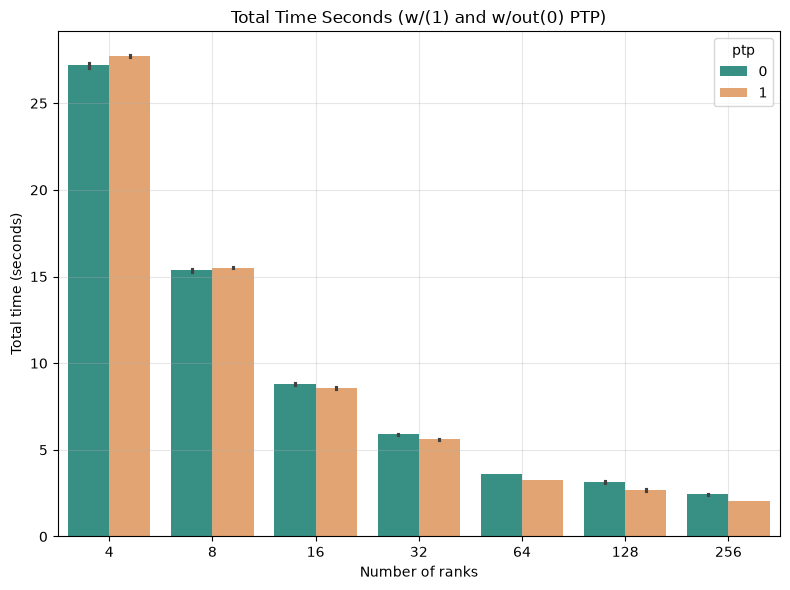

In [16]:
custom_palette = {
    0 : "#2A9D8F",
    1 : "#F4A261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_total_seconds",
    hue="ptp",
    palette=custom_palette
)

plt.xlabel("Number of ranks")
plt.ylabel("Total time (seconds)")
plt.title("Total Time Seconds (w/(1) and w/out(0) PTP)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

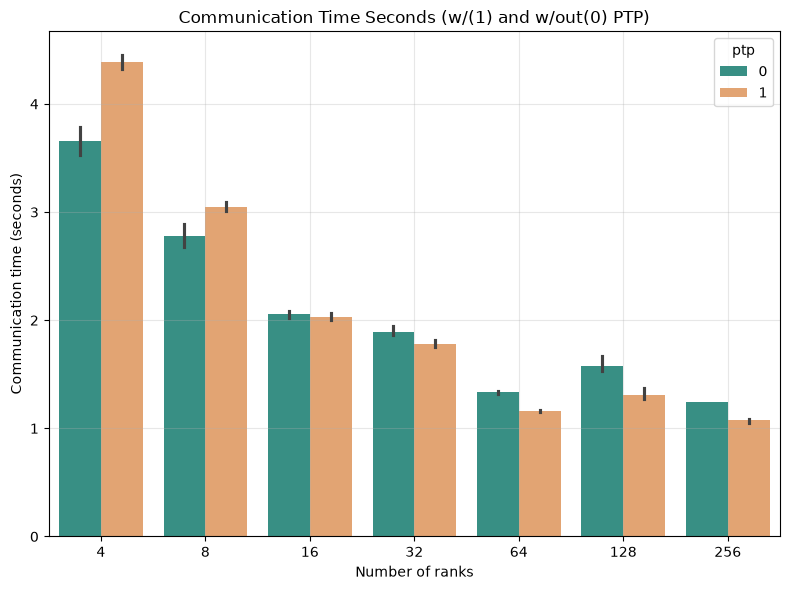

In [17]:
custom_palette = {
    0 : "#2A9D8F",
    1 : "#F4A261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_communication_seconds",
    hue="ptp",
    palette=custom_palette
)

plt.xlabel("Number of ranks")
plt.ylabel("Communication time (seconds)")
plt.title("Communication Time Seconds (w/(1) and w/out(0) PTP)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Results are not as expected. To be honest, quite the opposite.